In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [67]:
df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")
df = df.drop(columns=["Unnamed: 0"])

In [68]:
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [69]:
df.shape

(23486, 10)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended IND          23486 non-null  int64 
 6   Positive Feedback Count  23486 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 1.8+ MB


In [71]:
df.describe()

,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,918.118709,43.198544,4.196032,0.822362,2.535936
std,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,18.000000,1.000000,0.000000,0.000000
25%,861.000000,34.000000,4.000000,1.000000,0.000000
50%,936.000000,41.000000,5.000000,1.000000,1.000000
75%,1078.000000,52.000000,5.000000,1.000000,3.000000
max,1205.000000,99.000000,5.000000,1.000000,122.000000


In [72]:
df.isnull().sum().sort_values(ascending=False)

Title                      3810
Review Text                 845
Division Name                14
Department Name              14
Class Name                   14
Clothing ID                   0
Age                           0
Rating                        0
Recommended IND               0
Positive Feedback Count       0
dtype: int64

In [73]:
df.nunique()

Clothing ID                 1206
Age                           77
Title                      13993
Review Text                22634
Rating                         5
Recommended IND                2
Positive Feedback Count       82
Division Name                  3
Department Name                6
Class Name                    20
dtype: int64

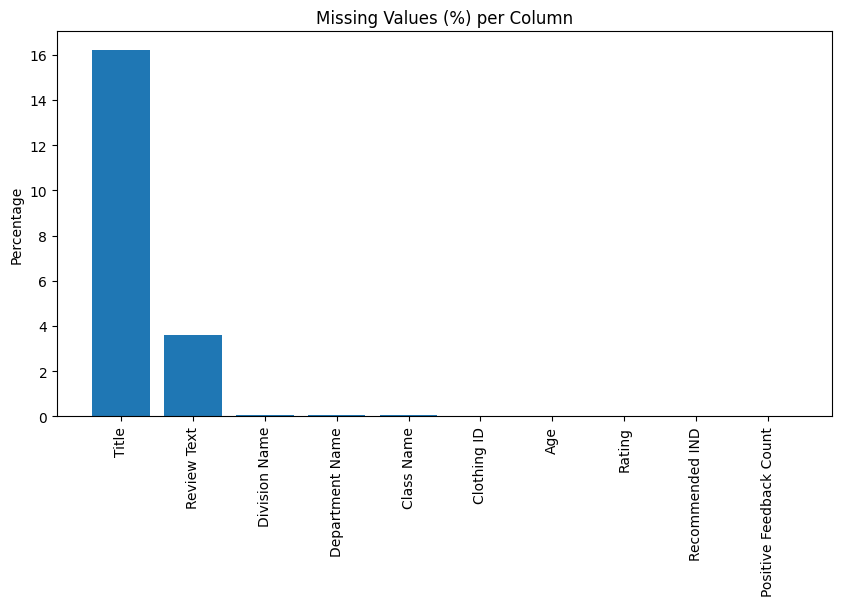

In [74]:
missing = df.isnull().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10,5))
plt.bar(missing.index, missing.values)
plt.xticks(rotation=90)
plt.title("Missing Values (%) per Column")
plt.ylabel("Percentage")
plt.show()

Rows with missing values in Division Name, Department Name, and Class Name were removed because they represent a very small portion of the dataset (~0.06%). Removing them does not affect the distribution or introduce bias, while ensuring cleaner categorical analysis.

In [75]:
df = df.dropna(subset=["Division Name", "Department Name", "Class Name"])

Missing values in Review Text and Title were not removed because they represent user behavior (absence of written feedback) rather than data corruption. These fields were filled with empty strings to preserve dataset size and avoid bias. Only rows missing product hierarchy fields were removed, as they are essential for categorical analysis.

In [76]:
df["Review Text"] = df["Review Text"].fillna("")
df["Title"] = df["Title"].fillna("")

In [77]:
df.shape

(23472, 10)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23472 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23472 non-null  int64 
 1   Age                      23472 non-null  int64 
 2   Title                    23472 non-null  object
 3   Review Text              23472 non-null  object
 4   Rating                   23472 non-null  int64 
 5   Recommended IND          23472 non-null  int64 
 6   Positive Feedback Count  23472 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.0+ MB


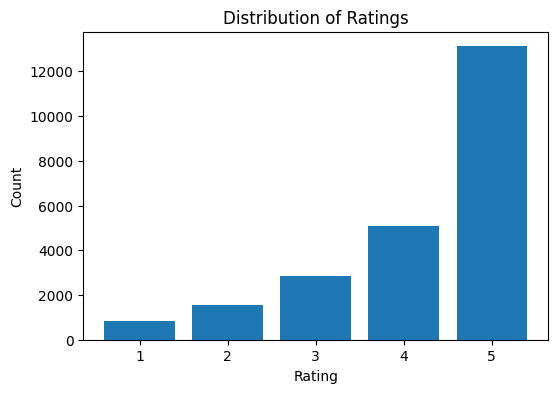

In [79]:
ratings = df["Rating"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(ratings.index, ratings.values)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

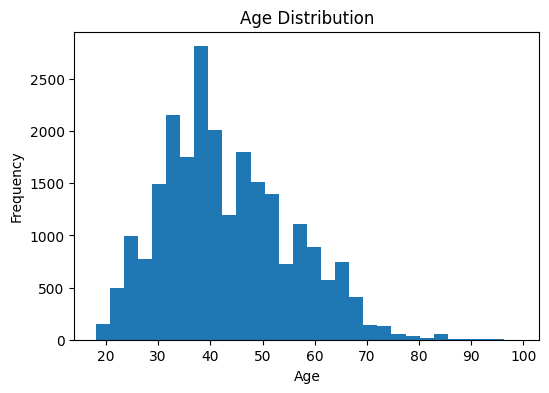

In [80]:
plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

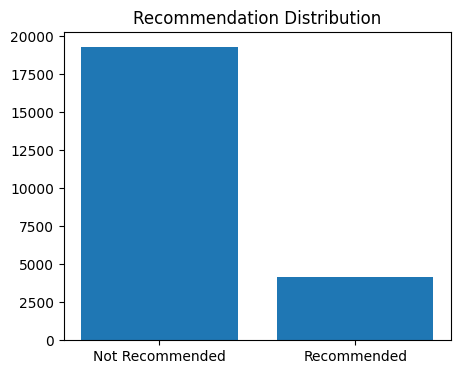

In [81]:
rec = df["Recommended IND"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(["Not Recommended", "Recommended"], rec.values)
plt.title("Recommendation Distribution")
plt.show()

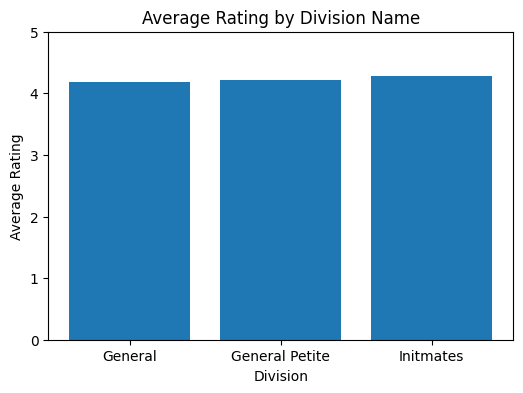

In [82]:
division_rating = df.groupby("Division Name")["Rating"].mean()

plt.figure(figsize=(6,4))
plt.bar(division_rating.index, division_rating.values)

plt.title("Average Rating by Division Name")
plt.xlabel("Division")
plt.ylabel("Average Rating")
plt.ylim(0,5)

plt.show()

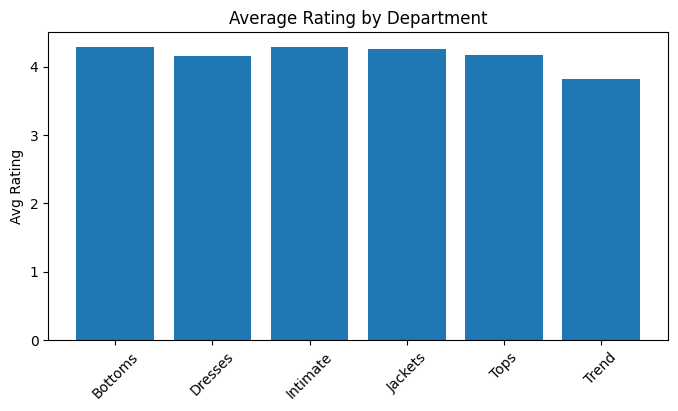

In [83]:
dept = df.groupby("Department Name")["Rating"].mean()

plt.figure(figsize=(8,4))
plt.bar(dept.index, dept.values)
plt.title("Average Rating by Department")
plt.xticks(rotation=45)
plt.ylabel("Avg Rating")
plt.show()

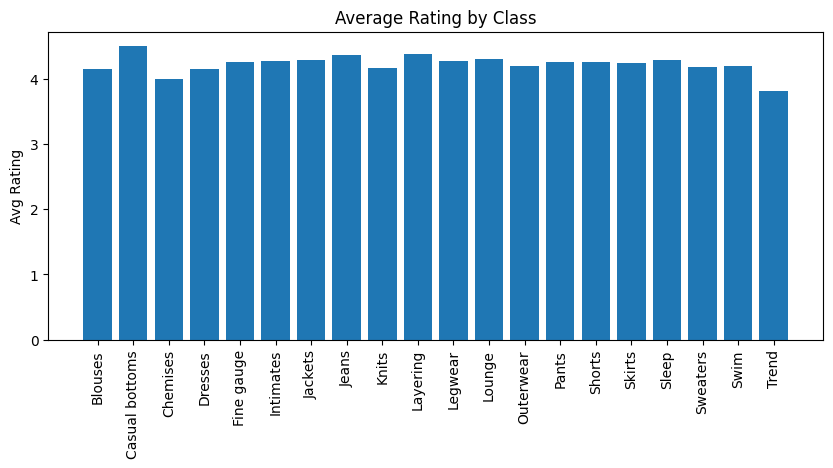

In [84]:
cls = df.groupby("Class Name")["Rating"].mean()

plt.figure(figsize=(10,4))
plt.bar(cls.index, cls.values)
plt.title("Average Rating by Class")
plt.xticks(rotation=90)
plt.ylabel("Avg Rating")
plt.show()

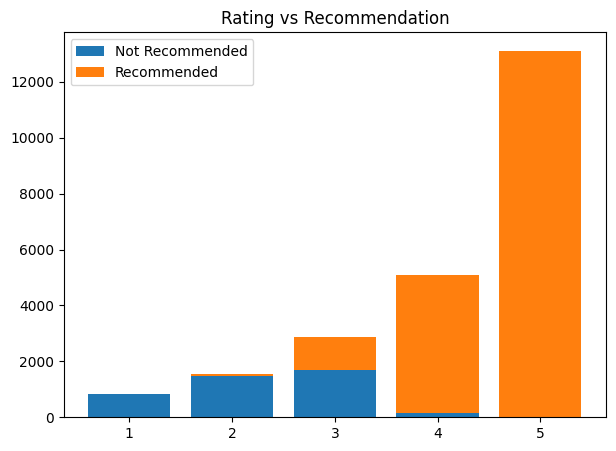

In [85]:
ratings = sorted(df["Rating"].unique())

rec_0 = []
rec_1 = []

for r in ratings:
    temp = df[df["Rating"] == r]
    rec_0.append((temp["Recommended IND"] == 0).sum())
    rec_1.append((temp["Recommended IND"] == 1).sum())

plt.figure(figsize=(7,5))
plt.bar(ratings, rec_0, label="Not Recommended")
plt.bar(ratings, rec_1, bottom=rec_0, label="Recommended")

plt.title("Rating vs Recommendation")
plt.legend()
plt.show()

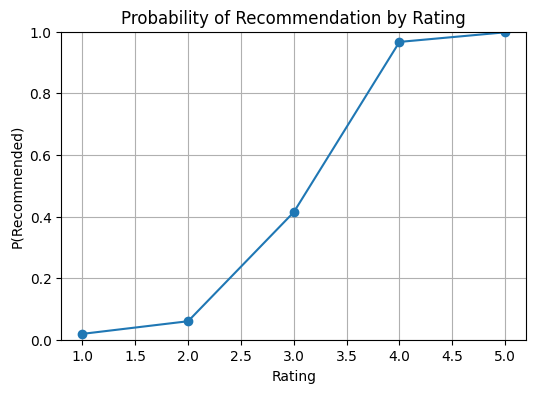

In [86]:
rec_rate = df.groupby("Rating")["Recommended IND"].mean()

plt.figure(figsize=(6,4))
plt.plot(rec_rate.index, rec_rate.values, marker="o")
plt.title("Probability of Recommendation by Rating")
plt.xlabel("Rating")
plt.ylabel("P(Recommended)")
plt.ylim(0,1)
plt.grid()
plt.show()

/var/folders/18/vvthhvh17bjcfkgkdtj19ptr0000gn/T/ipykernel_17963/851177037.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


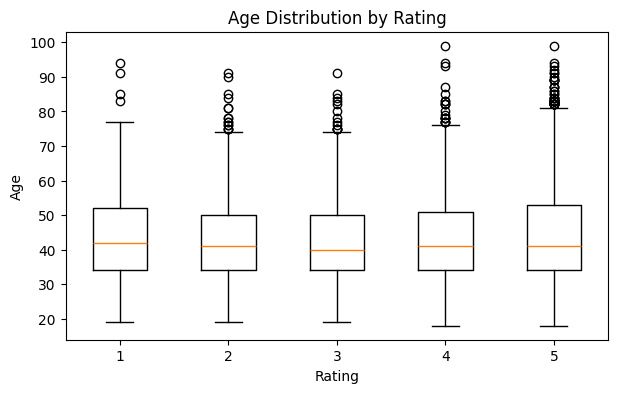

In [87]:
plt.figure(figsize=(7,4))
plt.boxplot(
    [df[df["Rating"] == r]["Age"] for r in sorted(df["Rating"].unique())],
    labels=sorted(df["Rating"].unique()),
)

plt.title("Age Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Age")
plt.show()

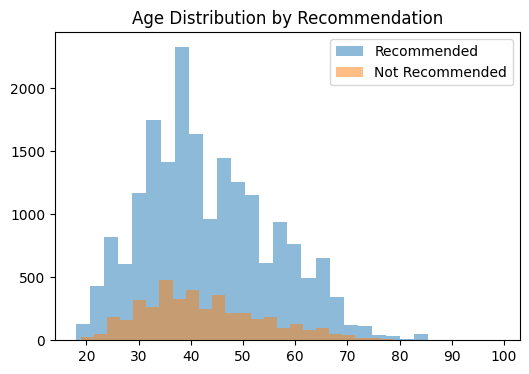

In [88]:
plt.figure(figsize=(6,4))

plt.hist(df[df["Recommended IND"]==1]["Age"], bins=30, alpha=0.5, label="Recommended")
plt.hist(df[df["Recommended IND"]==0]["Age"], bins=30, alpha=0.5, label="Not Recommended")

plt.title("Age Distribution by Recommendation")
plt.legend()
plt.show()

/var/folders/18/vvthhvh17bjcfkgkdtj19ptr0000gn/T/ipykernel_17963/4042438525.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


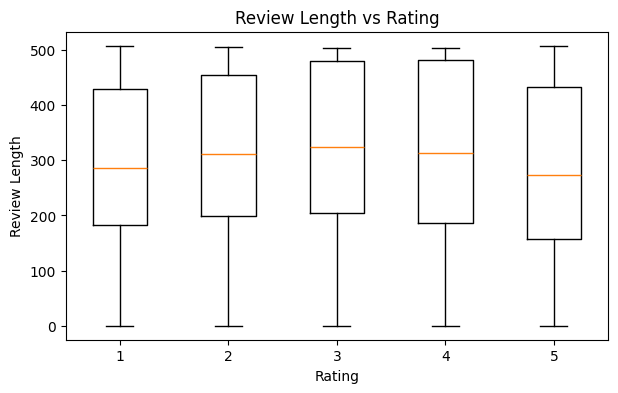

In [89]:
df["review_length"] = df["Review Text"].str.len()

plt.figure(figsize=(7,4))
plt.boxplot(
    [df[df["Rating"] == r]["review_length"] for r in sorted(df["Rating"].unique())],
    labels=sorted(df["Rating"].unique())
)

plt.title("Review Length vs Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length")
plt.show()

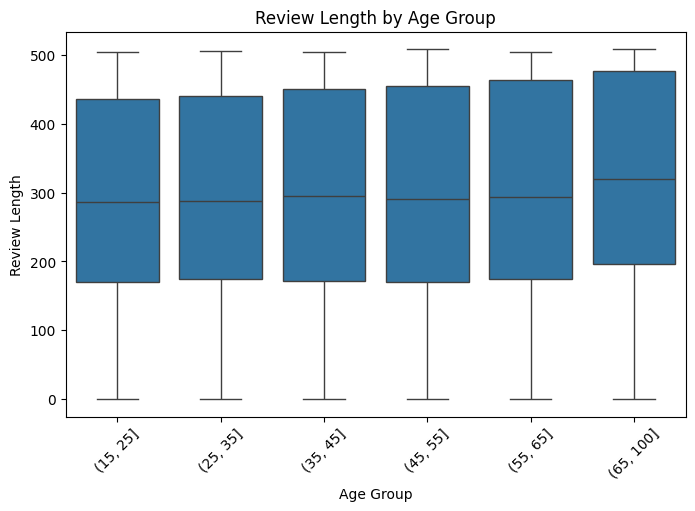

In [90]:
df["age_group"] = pd.cut(df["Age"], bins=[15,25,35,45,55,65,100])

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="age_group",
    y="review_length"
)

plt.title("Review Length by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Review Length")
plt.xticks(rotation=45)
plt.show()

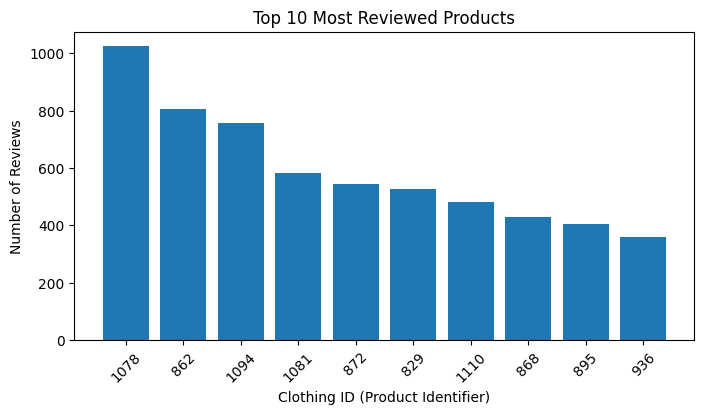

In [91]:
top = df["Clothing ID"].value_counts().head(10)

plt.figure(figsize=(8,4))
plt.bar(top.index.astype(str), top.values)

plt.title("Top 10 Most Reviewed Products")
plt.xlabel("Clothing ID (Product Identifier)")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)
plt.show()

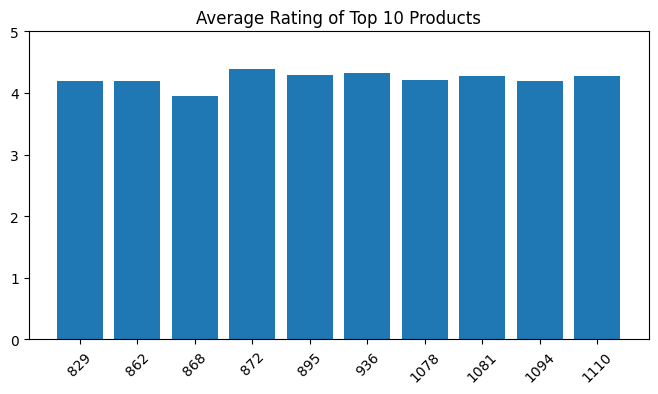

In [92]:
top_ids = df["Clothing ID"].value_counts().head(10).index

top_products = df[df["Clothing ID"].isin(top_ids)]
avg_rating = top_products.groupby("Clothing ID")["Rating"].mean()

plt.figure(figsize=(8,4))
plt.bar(avg_rating.index.astype(str), avg_rating.values)
plt.title("Average Rating of Top 10 Products")
plt.xticks(rotation=45)
plt.ylim(0,5)
plt.show()

In [93]:
top_ids = df["Clothing ID"].value_counts().head(10).index
top_df = df[df["Clothing ID"].isin(top_ids)]

summary = top_df.groupby("Clothing ID").agg(
    avg_rating=("Rating", "mean"),
    num_reviews=("Rating", "count"),
    rec_rate=("Recommended IND", "mean"),
    department=("Department Name", "first"),
    review_length=("review_length", "mean"),
    class_name=("Class Name", "first")
).reset_index().sort_values("num_reviews", ascending=False)

summary

,Clothing ID,avg_rating,num_reviews,rec_rate,department,review_length,class_name
6,1078,4.204102,1024,0.821289,Dresses,308.522461,Dresses
1,862,4.200993,806,0.820099,Tops,271.167494,Knits
8,1094,4.189153,756,0.821429,Dresses,320.982804,Dresses
7,1081,4.281787,582,0.848797,Dresses,315.764605,Dresses
3,872,4.383486,545,0.877064,Tops,271.042202,Knits
0,829,4.193548,527,0.827324,Tops,296.859583,Blouses
9,1110,4.281250,480,0.839583,Dresses,341.420833,Dresses
2,868,3.946512,430,0.755814,Tops,284.506977,Knits
4,895,4.299505,404,0.844059,Tops,280.490099,Fine gauge
5,936,4.326816,358,0.821229,Tops,306.692737,Sweaters


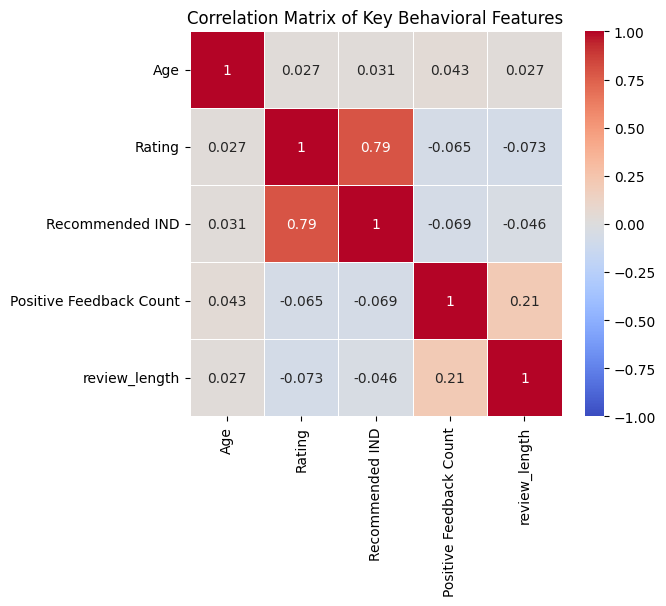

In [94]:
cols = ["Age", "Rating", "Recommended IND", "Positive Feedback Count", "review_length"]

corr = df[cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)

plt.title("Correlation Matrix of Key Behavioral Features")
plt.show()